K = 1 | Accuracy = 0.97
K = 2 | Accuracy = 0.93
K = 3 | Accuracy = 0.93
K = 4 | Accuracy = 0.93
K = 5 | Accuracy = 0.93
K = 6 | Accuracy = 0.93
K = 7 | Accuracy = 0.97
K = 8 | Accuracy = 0.93
K = 9 | Accuracy = 0.97
K = 10 | Accuracy = 0.97
K = 11 | Accuracy = 0.97
K = 12 | Accuracy = 0.97
K = 13 | Accuracy = 0.97
K = 14 | Accuracy = 0.93
K = 15 | Accuracy = 0.93


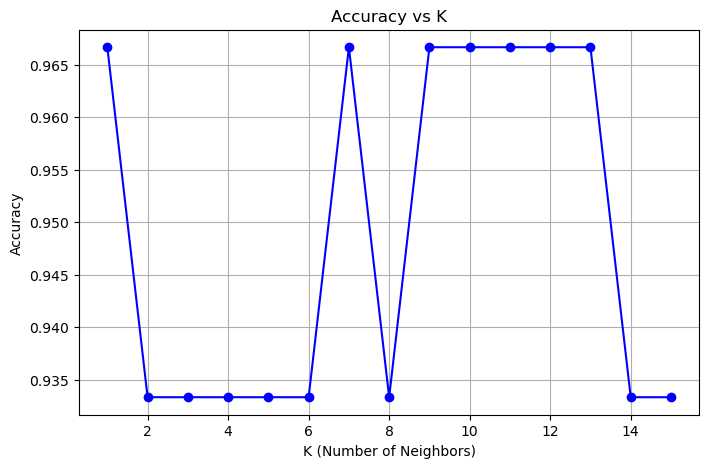


Best K: 1

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]

Accuracy: 0.9666666666666667


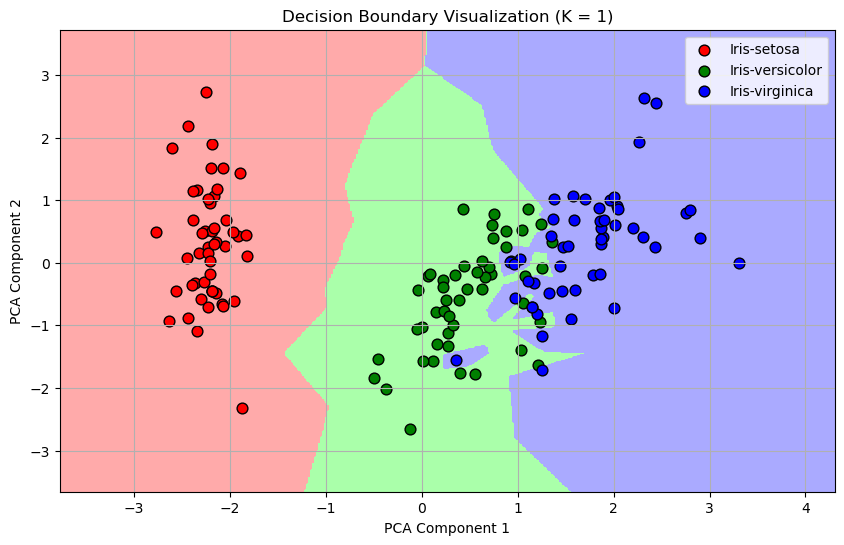

In [1]:
# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.decomposition import PCA

# Step 2: Load Dataset
df = pd.read_csv("Iris.csv")  # Make sure this file exists in your directory

# Step 3: Preprocessing
X = df.drop(columns=['Id', 'Species'])
y = df['Species']

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Step 5: Train KNN with multiple K values
k_values = range(1, 16)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"K = {k} | Accuracy = {acc:.2f}")

# Plot accuracy vs K
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', color='blue')
plt.title("Accuracy vs K")
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# Best K
best_k = k_values[np.argmax(accuracies)]
print(f"\nBest K: {best_k}")

# Step 6: Evaluate Best Model
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)
y_pred = best_knn.predict(X_test)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nAccuracy:", accuracy_score(y_test, y_pred))

# Step 7: Visualize Decision Boundary using PCA
pca = PCA(n_components=2)
X_vis = pca.fit_transform(X_scaled)

X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_vis, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

knn_vis = KNeighborsClassifier(n_neighbors=best_k)
knn_vis.fit(X_train_vis, y_train_vis)

# Create meshgrid
h = 0.02
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(10, 6))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ['red', 'green', 'blue']
plt.contourf(xx, yy, Z, cmap=cmap_light)

for idx, label in enumerate(np.unique(y_encoded)):
    plt.scatter(X_vis[y_encoded == label, 0], X_vis[y_encoded == label, 1],
                label=le.inverse_transform([label])[0],
                edgecolor='k', s=60, color=cmap_bold[idx])

plt.title(f"Decision Boundary Visualization (K = {best_k})")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True)
plt.show()
